## INTBREW STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

intbrew=pd.read_csv('../stock_data/intbrew.csv') ## so it can be small letter. This is cool.
intbrew=intbrew.drop(columns=['high_price','low_price'])
intbrew.rename(columns={'trade_date':'date'},inplace=True)
intbrew['date']=pd.to_datetime(intbrew['date'])
intbrew['month']=intbrew['date'].dt.month
intbrew['quarter']=intbrew['date'].dt.quarter
intbrew['year']=intbrew['date'].dt.year

intbrew

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42790,INTBREW,2017-01-03,18.50,18.50,9637,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43350,INTBREW,2017-01-04,18.50,18.50,602,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43460,INTBREW,2017-01-05,18.50,18.50,7207,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43570,INTBREW,2017-01-06,18.50,18.50,50,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43660,INTBREW,2017-01-09,18.50,18.50,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298076,INTBREW,2026-07-13,14.60,14.60,26763809,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298514,INTBREW,2026-07-14,13.90,13.90,7702551,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298952,INTBREW,2026-07-15,13.05,13.05,3359235,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299390,INTBREW,2026-07-16,13.25,13.25,949567,2026-07-16T15:10:03.113936+00:00,7,3,2026


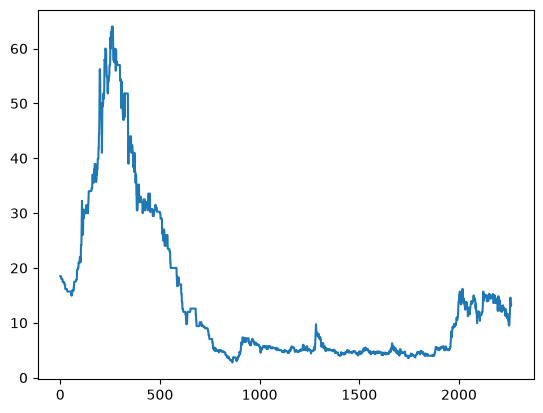

In [2]:
import matplotlib.pyplot as plt

plt.plot(intbrew['close_price'])
plt.show()

In [3]:
intbrew_end_month_df = (
    intbrew
    .sort_values("date")
    .groupby(intbrew["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

intbrew_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45360,INTBREW,2017-01-31,17.29,17.29,2122114,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47181,INTBREW,2017-02-28,15.70,15.70,302,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49297,INTBREW,2017-03-31,16.00,16.00,50,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51125,INTBREW,2017-04-28,17.84,17.84,1174,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53047,INTBREW,2017-05-31,21.05,21.05,121139,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35313,INTBREW,2026-03-31,14.00,14.00,1228495,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281139,INTBREW,2026-04-30,12.10,12.10,2770192,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284205,INTBREW,2026-05-29,12.55,12.55,461036,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294133,INTBREW,2026-06-30,10.50,10.50,1153056,2026-06-30T15:10:03.08168+00:00,6,2,2026


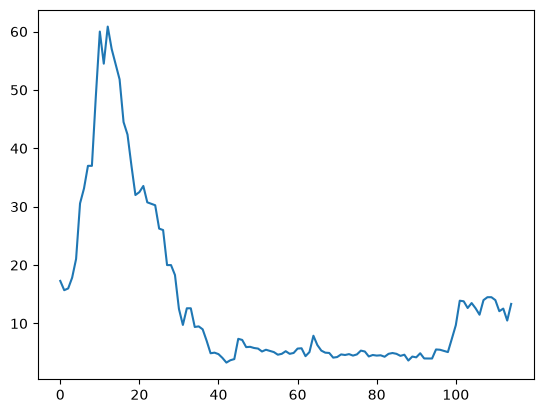

In [4]:
plt.plot(intbrew_end_month_df['close_price'])
plt.show()

In [5]:
intbrew_end_month_df['returns']=intbrew_end_month_df['close_price'].pct_change()*100
intbrew_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45360,INTBREW,2017-01-31,17.29,17.29,2122114,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47181,INTBREW,2017-02-28,15.70,15.70,302,2026-04-08T02:44:45.006295+00:00,2,1,2017,-9.196067
2,49297,INTBREW,2017-03-31,16.00,16.00,50,2026-04-08T02:45:42.281198+00:00,3,1,2017,1.910828
3,51125,INTBREW,2017-04-28,17.84,17.84,1174,2026-04-08T02:51:55.619599+00:00,4,2,2017,11.500000
4,53047,INTBREW,2017-05-31,21.05,21.05,121139,2026-04-08T02:52:57.421655+00:00,5,2,2017,17.993274
...,...,...,...,...,...,...,...,...,...,...,...
110,35313,INTBREW,2026-03-31,14.00,14.00,1228495,2026-03-31T15:00:02.085058+00:00,3,1,2026,-3.448276
111,281139,INTBREW,2026-04-30,12.10,12.10,2770192,2026-04-30T15:00:02.170664+00:00,4,2,2026,-13.571429
112,284205,INTBREW,2026-05-29,12.55,12.55,461036,2026-05-29T15:00:02.455558+00:00,5,2,2026,3.719008
113,294133,INTBREW,2026-06-30,10.50,10.50,1153056,2026-06-30T15:10:03.08168+00:00,6,2,2026,-16.334661


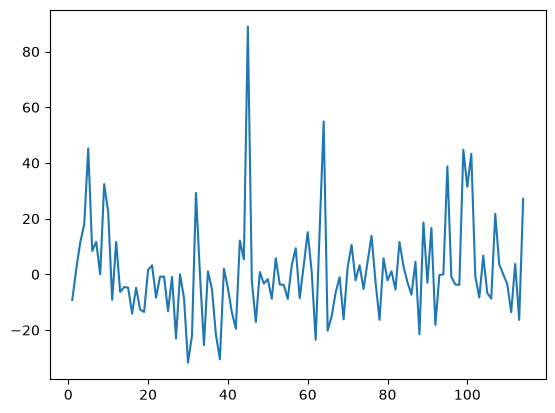

In [6]:
plt.plot(intbrew_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(intbrew_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-9.270132108627706), np.float64(1.3337175424168834e-15), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(860.6846990959956))
stationary


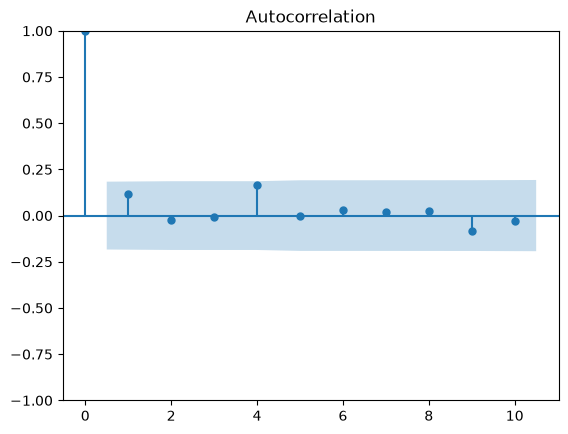

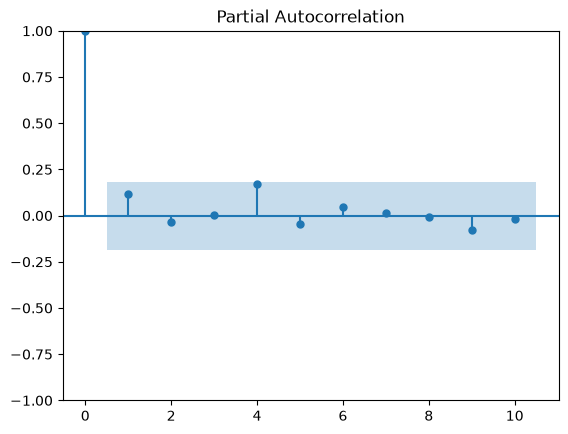

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(intbrew_end_month_df['returns'].dropna(), lags=10)
plot_pacf(intbrew_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=intbrew_end_month_df['close_price'][:-10]
test=intbrew_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -103.17685361508694]
[0, 0, 0, 0, 0, 1, -75.9755761093105]
[0, 0, 0, 0, 0, 2, -41.488069640393164]
[0, 0, 0, 0, 1, 0, -29.015719638798448]
[0, 0, 0, 0, 1, 1, -29.08255160176419]
[0, 0, 0, 0, 1, 2, -32.90417711041844]
[0, 0, 0, 0, 2, 0, -42.13914245346993]
[0, 0, 0, 0, 2, 1, -65.93863586488379]
[0, 0, 0, 0, 2, 2, -49.08114137660728]
[0, 0, 0, 1, 0, 0, -37.716290454531816]
[0, 0, 0, 1, 0, 1, -55.4529327029426]
[0, 0, 0, 1, 0, 2, -55.001619656326206]
[0, 0, 0, 1, 1, 0, -29.04338126435526]
[0, 0, 0, 1, 1, 1, -38.529303277828376]
[0, 0, 0, 1, 1, 2, -20.397565135540187]
[0, 0, 0, 1, 2, 0, -33.78964858190365]
[0, 0, 0, 1, 2, 1, -60.309458425509774]
[0, 0, 0, 1, 2, 2, -59.50461546055122]
[0, 0, 0, 2, 0, 0, -40.374710957375775]
[0, 0, 0, 2, 0, 1, -54.566787227374384]
[0, 0, 0, 2, 0, 2, -44.51516020354319]
[0, 0, 0, 2, 1, 0, -29.79572038927948]
[0, 0, 0, 2, 1, 1, -30.4873508659218]
[0, 0, 0, 2, 1, 2, -18.734168123280302]
[0, 0, 0, 2, 2, 0, -35.71276887146109]
[0, 0, 0, 2, 2, 1

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-410.547785
177,0,2,0,1,2,0,-274.075696
179,0,2,0,1,2,2,-259.367357
186,0,2,0,2,2,0,-203.848300
188,0,2,0,2,2,2,-196.476786
...,...,...,...,...,...,...,...
513,2,0,1,0,0,0,-0.071206
270,1,0,1,0,0,0,-0.062209
252,1,0,0,1,0,0,-0.057455
648,2,2,0,0,0,0,-0.057424


Not good enough.

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=intbrew_end_month_df['returns'].dropna()[:-10]
test=intbrew_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.0030361607851512318]
[0, 0, 0, 0, 0, 1, -0.22277989393337205]
[0, 0, 0, 0, 0, 2, -0.22867630704644504]
[0, 0, 0, 0, 1, 0, -3.926831198850893]
[0, 0, 0, 0, 1, 1, -0.7304542148058493]
[0, 0, 0, 0, 1, 2, -1.1010262300338014]
[0, 0, 0, 0, 2, 0, -13.466360004790905]
[0, 0, 0, 0, 2, 1, -4.392713092526092]
[0, 0, 0, 0, 2, 2, -3.1195659398381013]
[0, 0, 0, 1, 0, 0, -0.15507880290214837]
[0, 0, 0, 1, 0, 1, -0.2483297273817786]
[0, 0, 0, 1, 0, 2, -0.23700907311519703]
[0, 0, 0, 1, 1, 0, -2.223233236870424]
[0, 0, 0, 1, 1, 1, -0.9505284191558547]
[0, 0, 0, 1, 1, 2, -1.067411328350031]
[0, 0, 0, 1, 2, 0, -8.07538038356696]
[0, 0, 0, 1, 2, 1, -3.2038175876684996]
[0, 0, 0, 1, 2, 2, -1.9336396378813072]
[0, 0, 0, 2, 0, 0, -0.15538445816550084]
[0, 0, 0, 2, 0, 1, -0.2303231628181841]
[0, 0, 0, 2, 0, 2, -0.3489352782689428]
[0, 0, 0, 2, 1, 0, -1.4904595809947496]
[0, 0, 0, 2, 1, 1, -1.0289183397123383]
[0, 0, 0, 2, 1, 2, -1.0228686486672354]
[0, 0, 0, 2, 2, 0, -5.352136618586404]

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
481,1,2,2,2,1,1,-1.509324e+07
168,0,2,0,0,2,0,-1.644304e+03
177,0,2,0,1,2,0,-1.310987e+03
186,0,2,0,2,2,0,-9.800425e+02
169,0,2,0,0,2,1,-7.661700e+02
...,...,...,...,...,...,...,...
54,0,0,2,0,0,0,-1.208783e-02
243,1,0,0,0,0,0,-1.148593e-02
0,0,0,0,0,0,0,-3.036161e-03
675,2,2,1,0,0,0,3.608391e-02


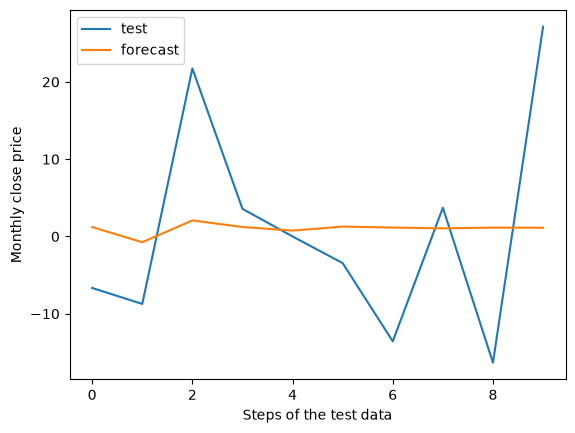

r2_score:  0.036776324789934534
rmse:  13.218350741781743
description:  count    114.000000
mean       1.132085
std       17.709618
min      -31.693989
25%       -8.461438
50%       -0.926641
75%        5.661696
max       88.974359
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=intbrew_end_month_df['returns'].dropna()[:-10]
y_test=intbrew_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', intbrew_end_month_df.returns.dropna().describe())

To be revisited.
